<a href="https://colab.research.google.com/github/Janardan-thapaliya/Deep_Learning_SNN/blob/main/N_Caltech101_HybridSNN_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Dataset/Caltech101.zip'
extract_to = '/content/dataset'  # Extract into Colab's temporary space

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

with zipfile.ZipFile("/content/Caltech101_annotations.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

os.listdir(extract_to)

['Caltech101', 'Caltech101_annotations']

In [1]:
import torch
from torch.utils.data import Dataset, random_split, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
import os

# Dataset paths
dataset_path = "/content/dataset/Caltech101"
annotation_path = "/content/dataset/Caltech101_annotations"

# Print number of classes and example files
def explore_dataset(base_path):
    classes = sorted(os.listdir(base_path))
    print(f"Total classes found: {len(classes)}\n")
    for cls in classes[:5]:  # show just first 5 classes
        class_path = os.path.join(base_path, cls)
        files = os.listdir(class_path)
        print(f"Class: {cls}, Samples: {len(files)}, First sample: {files[0]}")

explore_dataset(dataset_path)
explore_dataset(annotation_path)

Total classes found: 101

Class: BACKGROUND_Google, Samples: 467, First sample: image_0340.bin
Class: Faces_easy, Samples: 435, First sample: image_0340.bin
Class: Leopards, Samples: 200, First sample: image_0164.bin
Class: Motorbikes, Samples: 798, First sample: image_0340.bin
Class: accordion, Samples: 55, First sample: image_0010.bin
Total classes found: 100

Class: Faces_easy, Samples: 435, First sample: annotation_0102.bin
Class: Leopards, Samples: 200, First sample: annotation_0102.bin
Class: Motorbikes, Samples: 798, First sample: annotation_0102.bin
Class: accordion, Samples: 55, First sample: annotation_0050.bin
Class: airplanes, Samples: 800, First sample: annotation_0102.bin


In [3]:
def read_Ncaltech_file(file_path):
    x_coords, y_coords, polarities, timestamps = [], [], [], []
    with open(file_path, 'rb') as f:
        data = f.read()
        for i in range(0, len(data), 5):
            event = int.from_bytes(data[i:i+5], byteorder='big')
            x_coords.append((event >> 32) & 0xFF)
            y_coords.append((event >> 24) & 0xFF)
            polarities.append((event >> 23) & 0x01)
            timestamps.append(event & 0x7FFFFF)
    return x_coords, y_coords, polarities, timestamps

file_path = "/content/dataset/Caltech101/Motorbikes/image_0001.bin"
x, y, p, t = read_Ncaltech_file(file_path)

print(f"Events Loaded: {len(x)}")
print(f"x: {x[:10]}")
print(f"y: {y[:10]}")
print(f"polarity: {p[:10]}")
print(f"time: {t[:10]}")

Events Loaded: 128158
x: [216, 27, 88, 136, 100, 222, 58, 61, 230, 25]
y: [93, 86, 85, 71, 1, 49, 85, 120, 56, 82]
polarity: [1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
time: [11, 12, 36, 50, 64, 77, 98, 126, 145, 186]


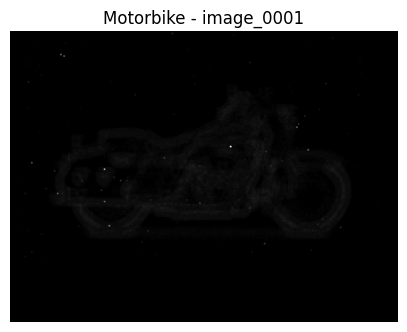

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_events(x, y, p, title="Event Frame"):
    img = np.zeros((180, 240))  # standard resolution
    for i in range(len(x)):
        img[y[i], x[i]] += 1 if p[i] == 1 else 0

    plt.figure(figsize=(5, 4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_events(x, y, p, title="Motorbike - image_0001")


In [5]:
#  Install dependencies
!pip install spikingjelly torch torchvision matplotlib scikit-learn tqdm --quiet

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from spikingjelly.clock_driven import neuron, surrogate, functional
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score


In [6]:
#  Dataset: Time-Series + Frame

class NCaltech101HybridDataset(Dataset):
    def __init__(self, data_dir, classes, time_window=100, resolution=(240, 240)):
        self.data_dir = data_dir
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []
        self.time_window = time_window
        self.res = resolution

        for cls in classes:
            class_dir = os.path.join(data_dir, cls)
            for f in os.listdir(class_dir):
                if f.endswith('.bin'):
                    self.samples.append((os.path.join(class_dir, f), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        data = np.fromfile(file_path, dtype=np.uint8).reshape(-1, 5)
        x, y, t = data[:, 0], data[:, 1], data[:, 2].astype(np.int32)
        t = t - t.min()

        frames = np.zeros((self.time_window, *self.res))  # [T, H, W]
        collapse_frame = np.zeros(self.res)  # [H, W]

        for xi, yi, ti in zip(x, y, t):
            if ti < self.time_window:
                frames[ti, yi, xi] += 1
                collapse_frame[yi, xi] += 1

        frames = torch.tensor(frames, dtype=torch.float32).clamp(0, 1).unsqueeze(1)  # [T, 1, H, W]
        collapse_frame = torch.tensor(collapse_frame, dtype=torch.float32).clamp(0, 1).unsqueeze(0)  # [1, H, W]
        return frames, collapse_frame, label

In [7]:
# Hybrid Model
# -------------------------------
class HybridNet(nn.Module):
    def __init__(self, num_classes, time_window=100):
        super().__init__()
        self.time_window = time_window

        # SNN Branch
        self.snn_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.snn_lif1 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.snn_pool1 = nn.MaxPool2d(2)

        self.snn_conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.snn_lif2 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.snn_pool2 = nn.MaxPool2d(2)

        self.snn_conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.snn_lif3 = neuron.LIFNode(surrogate_function=surrogate.Sigmoid())
        self.snn_pool3 = nn.MaxPool2d(2)

        # CNN Branch
        self.cnn_conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.cnn_pool1 = nn.MaxPool2d(2)

        self.cnn_conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.cnn_pool2 = nn.MaxPool2d(2)

        self.cnn_conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.cnn_pool3 = nn.MaxPool2d(2)

        # Fusion + FC
        self.fc1 = nn.Linear((64 * 30 * 30) + (128 * 30 * 30), 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, spike_x, frame_x):  # spike_x: [T, B, 1, H, W], frame_x: [B, 1, H, W]
        functional.reset_net(self)

        B = spike_x.shape[1]
        snn_out = 0

        # SNN Branch
        for t in range(self.time_window):
            x = self.snn_conv1(spike_x[t])
            x = self.snn_lif1(x)
            x = self.snn_pool1(x)

            x = self.snn_conv2(x)
            x = self.snn_lif2(x)
            x = self.snn_pool2(x)

            x = self.snn_conv3(x)
            x = self.snn_lif3(x)
            x = self.snn_pool3(x)

            snn_out += x

        snn_out = snn_out / self.time_window
        snn_out = snn_out.view(B, -1)

        # CNN Branch
        x = F.relu(self.cnn_conv1(frame_x))
        x = self.cnn_pool1(x)
        x = F.relu(self.cnn_conv2(x))
        x = self.cnn_pool2(x)
        x = F.relu(self.cnn_conv3(x))
        x = self.cnn_pool3(x)
        cnn_out = x.view(B, -1)

        # Combine
        out = torch.cat([snn_out, cnn_out], dim=1)
        out = self.dropout(F.relu(self.fc1(out)))
        return self.fc2(out)

In [8]:
# Train / Eval
# -------------------------------
def train(model, loader, optimizer, loss_fn, device):
    model.train()
    for spike_x, frame_x, y in tqdm(loader, desc="Training"):
        spike_x, frame_x, y = spike_x.to(device), frame_x.to(device), y.to(device)
        spike_x = spike_x.permute(1, 0, 2, 3, 4)  # [B, T, C, H, W] -> [T, B, C, H, W]
        optimizer.zero_grad()
        out = model(spike_x, frame_x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for spike_x, frame_x, y in loader:
            spike_x, frame_x, y = spike_x.to(device), frame_x.to(device), y.to(device)
            spike_x = spike_x.permute(1, 0, 2, 3, 4)
            out = model(spike_x, frame_x)
            total_loss += loss_fn(out, y).item()
            all_preds.append(out.argmax(1).cpu().numpy())
            all_labels.append(y.cpu().numpy())

    acc = accuracy_score(np.concatenate(all_labels), np.concatenate(all_preds))
    return total_loss / len(loader), acc

In [9]:
# Main
# -------------------------------
if __name__ == "__main__":
    TIME_WINDOW = 70
    BATCH_SIZE = 8
    EPOCHS = 25
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(dataset_path):
        !wget -q https://www.garrickorchard.com/datasets/n-caltech101.zip
        !unzip -q n-caltech101.zip -d /content
        !mv /content/n-Caltech101 /content/ncaltech101

    CLASSES = sorted(os.listdir(dataset_path))
    dataset = NCaltech101HybridDataset(dataset_path, CLASSES, TIME_WINDOW)

    train_len = int(0.8 * len(dataset))
    test_len = len(dataset) - train_len
    train_ds, test_ds = random_split(dataset, [train_len, test_len])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=1)

    model = HybridNet(num_classes=len(CLASSES), time_window=TIME_WINDOW).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        train(model, train_loader, optimizer, loss_fn, DEVICE)
        val_loss, val_acc = evaluate(model, test_loader, loss_fn, DEVICE)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
        scheduler.step()

    print("\n Final Evaluation on Test Set:")
    final_loss, final_acc = evaluate(model, test_loader, loss_fn, DEVICE)
    print(f"Final Loss: {final_loss:.4f} | Final Accuracy: {final_acc:.4f}")

    # Save the model weights
    torch.save(model.state_dict(), 'event_hybrid_model.pth')
    print("Model saved as event_hybrid_model.pth")

    #Entire model save
    torch.save(model, 'event_hybrid_entire_model.pth')
    # Load later with:
    # model = torch.load('event_hybrid_entire_model.pth')
    # model.eval()


Epoch 1/25


Training: 100%|██████████| 871/871 [19:57<00:00,  1.38s/it]


Validation Loss: 2.8645, Accuracy: 0.3766

Epoch 2/25


Training: 100%|██████████| 871/871 [20:00<00:00,  1.38s/it]


Validation Loss: 2.3816, Accuracy: 0.4569

Epoch 3/25


...

Validation Loss: 5.6260, Accuracy: 0.4966

Epoch 24/25


Training: 100%|██████████| 871/871 [19:53<00:00,  1.37s/it]


Validation Loss: 5.9034, Accuracy: 0.5006

Epoch 25/25


Training: 100%|██████████| 871/871 [19:52<00:00,  1.37s/it]


Validation Loss: 5.9084, Accuracy: 0.5046

 Final Evaluation on Test Set:
Final Loss: 5.9084 | Final Accuracy: 0.5046
Model saved as event_hybrid_model.pth


In [10]:
import os
from google.colab import files

paths = [
    '/content/event_hybrid_model.pth',
    '/content/event_hybrid_entire_model.pth'
]

for path in paths:
    if os.path.exists(path):
        files.download(path)
    else:
        print(f" File not found: {path}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
final_loss, final_acc = evaluate(model, train_loader, loss_fn, DEVICE)
print(f"Final Loss on train: {final_loss:.4f} | Final Accuracy on train: {final_acc:.4f}")

Final Loss on train: 0.0009 | Final Accuracy on train: 1.0000


In [13]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for spike_x, frame_x, labels in test_loader: # Changed this line to unpack 3 values
        spike_x, frame_x, labels = spike_x.to(DEVICE), frame_x.to(DEVICE), labels.to(DEVICE)
        spike_x = spike_x.permute(1, 0, 2, 3, 4)  # Reshape for the SNN branch
        outputs = model(spike_x, frame_x) # Pass both spike and frame data to the model
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.item())
        all_labels.append(labels.item())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

                   precision    recall  f1-score   support

BACKGROUND_Google       0.18      0.39      0.25       101
       Faces_easy       0.88      1.00      0.94        80
         Leopards       0.78      0.88      0.82        48
       Motorbikes       0.95      1.00      0.98       166
        accordion       0.47      0.78      0.58         9
        airplanes       0.94      0.99      0.96       166
           anchor       0.00      0.00      0.00         6
              ant       0.00      0.00      0.00         8
           barrel       0.00      0.00      0.00         8
             bass       0.00      0.00      0.00         8
           beaver       0.00      0.00      0.00         9
        binocular       0.00      0.00      0.00         2
           bonsai       0.31      0.37      0.34        27
            brain       0.38      0.38      0.38        16
     brontosaurus       0.38      0.38      0.38         8
           buddha       0.61      0.48      0.54       

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
